# TD Learning: SARSA e *Q*-learning

#### Prof. Armando Alves Neto - Introdução ao Aprendizado por Reforço - PPGEE/UFMG

##### Alunos: Henrique Marques Cruz e Matheus Tadeu Alves de Carvalho

---

## Introdução

O objetivo deste notebook é treinar um agente para jogar Blackjack usando dois algoritmos clássicos de TD Learning: **SARSA** e ***Q*-learning**. A implementação utiliza a biblioteca `gymnasium` com o ambiente `Blackjack-v1`.

O Blackjack é um jogo de cartas amplamente usado como problema de referência em aprendizado por reforço (Sutton & Barto, Cap. 5). O objetivo é obter cartas cuja soma seja a maior possível sem ultrapassar 21, competindo contra o dealer.

As regras relevantes são:
- Cartas de figura (Valete, Dama, Rei) valem **10 pontos**
- O Ás vale **11** (ás *utilizável*) ou **1** — sempre se usa 11 enquanto não estourar
- Cartas numéricas valem seu **valor nominal**
- O dealer segue uma estratégia fixa: pede carta se sua soma for menor que 17, para caso contrário
- Se o jogador ultrapassar 21, ele perde imediatamente (*bust*)


Objetivo: ensinar um agente a jogar Blackjack (21) contra o dealer utilizando aprendizado por reforço.

## Formulação como MDP

Cada partida de Blackjack é um **episódio** de um MDP finito e episódico:

### Espaço de observações

A observação é uma tupla com 3 valores:
- **Soma do jogador**: valor entre 4 e 21
- **Carta visível do dealer**: valor entre 1 (ás) e 10
- **Ás utilizável**: 0 (não tem) ou 1 (tem ás contando como 11)

Isso resulta em $32 \times 11 \times 2 = 704$ estados possíveis.
(32 porque o menor valor de soma é 0 e pode ir até 21+10)
### Espaço de ações

O agente pode escolher entre duas ações:
- **0 — Stick**: parar de pedir cartas
- **1 — Hit**: pedir mais uma carta

### Função de recompensa

- Vencer a partida: **+1**
- Perder a partida: **−1**
- Empate: **0**
- Blackjack natural (ás + 10 na primeira mão): **+1.5** (se `natural=True`)

In [1]:
import gymnasium as gym
import numpy as np
from functools import partial
from IPython.display import clear_output
import matplotlib.pyplot as plt

Criando a classe para o TD learning.

In [2]:
class TDlearning(object):
    _count = 0 # contador de instancias

    def __init__(self, parameters):

        # id da instancia
        self.id = TDlearning._count
        TDlearning._count += 1

        self.parameters = parameters

        # metodo
        self.method = parameters['method']

        # numero de episodios
        self.episode = 0

        # cria o ambiente Blackjack do Gymnasium
        # natural=True concede recompensa +1.5 para blackjack natural
        self.env = gym.make('Blackjack-v1', natural=parameters['natural'])

        # tamanho dos espacos de estados e acoes
        # obs: (soma_jogador, carta_dealer, as_utilizavel) -> 32 x 11 x 2 = 704 estados
        self.num_states_tuple = (32, 11, 2)  # limites de cada dimensao da observacao
        self.num_states = np.prod(self.num_states_tuple)
        self.num_actions = self.env.action_space.n  # 2 acoes: stick (0) ou hit (1)

        # parametros de aprendizado
        self.gamma     = parameters['gamma']
        self.alpha     = parameters['alpha']

        # epsilon com decaimento
        self.eps         = parameters['eps']        # epsilon inicial
        self.eps_min     = parameters['eps_min']    # epsilon minimo
        self.eps_decay   = parameters['eps_decay']  # fator multiplicativo de decaimento
        self.eps_history = []                       # historico do epsilon (apenas agente 0)

        # log file (nome depende do metodo)
        self.logfile = parameters['q-file']
        if self.method == 'SARSA':
            self.logfile = 'sarsa_' + self.logfile
        elif self.method == 'Q-learning':
            self.logfile = 'qlearning_' + self.logfile
        else: print("Não salvou...")

        # reseta a politica
        self.reset()

    ##########################################
    # converte a observacao (tupla 3D) em indice escalar para indexar Q(s,a)
    def obs_to_state(self, obs):
        # obs = (soma_jogador, carta_dealer, as_utilizavel)
        # np.ravel_multi_index converte indice multidimensional em indice linear
        return int(np.ravel_multi_index(obs, self.num_states_tuple))

    ##########################################
    # reseta a funcao acao-valor
    def reset(self):
        # reseta o ambiente e descarta info extra retornada pelo gymnasium
        obs, _ = self.env.reset()

        # Q(s,a): tabela de valor-acao inicializada em zero
        self.Q = np.zeros((self.num_states, self.num_actions))

        # carrega tabela pre-computada se for o caso
        if self.parameters['load_Q']:
            try:
                with open(self.logfile, 'rb') as f:
                    data = np.load(f)
                    self.Q = data['Q']
                    self.episode = data['episodes']
            except: None

    ##########################################
    # retorna a politica corrente
    def curr_policy(self, copy=False):
        if copy:
            return partial(self.tabular_epsilon_soft_policy, np.copy(self.Q))
        else:
            return partial(self.tabular_epsilon_soft_policy, self.Q)

    ########################################
    # salva tabela Q(s,a)
    def save(self):
        with open(self.logfile, 'wb') as f:
            np.savez(f, Q=self.Q, episodes=self.episode)


Probabilidade de escolha de uma ação $a$ baseada na política $\varepsilon$-soft:
$$
\pi(a|S_t) \gets
                    \begin{cases}
                        1 - \varepsilon + \varepsilon/|\mathcal{A}|,  & \text{se}~ a = \arg\max\limits_{a} Q(S_t,a),\\
                        \varepsilon/|\mathcal{A}|, & \text{caso contrário.}
                    \end{cases}
$$

In [3]:
class TDlearning(TDlearning):
    ##########################################
    # escolha da acao (epsilon-soft)
    def tabular_epsilon_soft_policy(self, Q, state):
        # probabilidades de escolher as acoes
        p1 = 1.0 - self.eps + self.eps/self.num_actions
        p2 = self.eps/self.num_actions
        prob = [p1 if a == Q[state, :].argmax() else p2 for a in range(self.num_actions)]

        return np.random.choice(self.num_actions, p=np.array(prob))

Método do SARSA:
- aplique ação $A$, receba $S'$ e $R$
- escolha $A'$ a partir de $S'$ usando $Q$ ($\varepsilon$-greedy, por exemplo)
- $Q(S,A) \gets Q(S,A) + \alpha \big[R + \gamma Q(S',A') - Q(S,A)\big]$
- $S \gets S'$
- $A \gets A'$

In [4]:
class TDlearning(TDlearning):
    ##########################################
    def sarsa(self, S, A):

        # passo de interacao com o ambiente
        # gymnasium retorna: obs, reward, terminated, truncated, info
        obs, R, terminated, truncated, _ = self.env.step(A)
        done = terminated or truncated

        # converte observacao em indice escalar
        Sl = self.obs_to_state(obs)

        # escolhe A' a partir de S'
        Al = self.policy(Sl)

        # update de Q(s,a)
        if done:
            self.Q[S, A] = self.Q[S, A] + self.alpha*(R - self.Q[S, A])
        else:
            self.Q[S, A] = self.Q[S, A] + self.alpha*(R + self.gamma*self.Q[Sl, Al] - self.Q[S, A])

        return Sl, Al, R, done

Método do *Q*-learning:
- escolha $A$ a partir de $S$ usando $Q$ ($\varepsilon$-greedy, por exemplo)
- aplique ação $A$, receba $S'$ e $R$
- $Q(S,A) \gets Q(S,A) + \alpha \big[R + \gamma \max\limits_a Q(S',a) - Q(S,A)\big]$
- $S \gets S'$

In [5]:
class TDlearning(TDlearning):
    ##########################################
    def qlearning(self, S):

        # \pi(s)
        A = self.policy(S)

        # passo de interacao com o ambiente
        # gymnasium retorna: obs, reward, terminated, truncated, info
        obs, R, terminated, truncated, _ = self.env.step(A)
        done = terminated or truncated

        # converte observacao em indice escalar
        Sl = self.obs_to_state(obs)

        # update de Q(s,a)
        if done:
            self.Q[S, A] = self.Q[S, A] + self.alpha*(R - self.Q[S, A])
        else:
            self.Q[S, A] = self.Q[S, A] + self.alpha*(R + self.gamma*self.Q[Sl, :].max() - self.Q[S, A])

        return Sl, R, done

Executando um episódio.

In [6]:
class TDlearning(TDlearning):
    ##########################################
    def run_episode(self):

        # novo episodio
        self.episode += 1

        # pega a politica corrente (on-policy)
        self.policy = self.curr_policy()

        # inicia o ambiente; gymnasium retorna (obs, info)
        obs, _ = self.env.reset()

        # converte a observacao inicial em indice escalar
        S = self.obs_to_state(obs)

        # \pi(s)
        A = self.policy(S)

        # lista de rewards
        rewards = []

        while True:
            # SARSA
            if self.method == 'SARSA':
                Sl, Al, R, done = self.sarsa(S, A)
                # proxima acao
                A = Al
            # Q-learning
            elif self.method == 'Q-learning':
                Sl, R, done = self.qlearning(S)
            else:
                print('Método errado.')

            # proximo estado
            S = Sl

            # salva rewards
            rewards.append(R)

            # chegou a um estado terminal?
            if done:
                break

        # decaimento do epsilon ao final do episodio
        # eps <- max(eps * eps_decay, eps_min)
        self.eps = max(self.eps * self.eps_decay, self.eps_min)

        # registra historico do epsilon (apenas agente 0, para plotar)
        if self.id == 0:
            self.eps_history.append(self.eps)

        # salva a tabela Q (apenas agente 0 salva, para evitar conflitos)
        if self.id == 0:
            if self.parameters['save_Q']:
                self.save()

        return np.sum(np.array(rewards))


Código principal:
- **episodes**: número de episódios
- **gamma**: fator de desconto
- **eps**: $\varepsilon$ inicial
- **eps_min**: $\varepsilon$ mínimo (piso do decaimento)
- **eps_decay**: fator multiplicativo de decaimento ($\varepsilon \leftarrow \max(\varepsilon \cdot \text{eps\_decay},\ \varepsilon_{\min})$)
- **alpha**: $\alpha$
- **method**: *SARSA* ou *Q-learning*
- **natural**: recompensa +1.5 para blackjack natural
- **save_Q**: salva tabela *Q*
- **load_Q**: carrega tabela *Q*
- **q-file**: arquivo da tabela *Q*
- **nagents**: número de agentes em paralelo


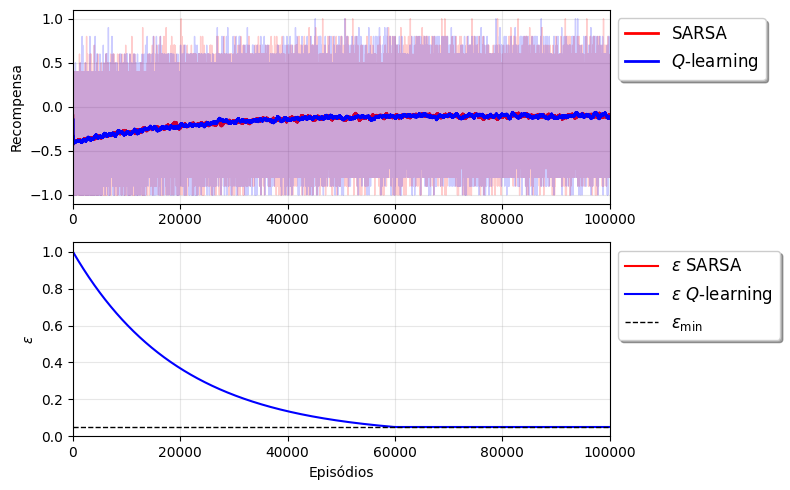

In [7]:
if __name__ == '__main__':

    plt.ion()
    plt.rcParams['figure.figsize'] = (8, 5)
    plt.figure(1)

    # parametros
    parameters = {'episodes'  : 100000,
                  'gamma'     : 0.95,
                  'eps'       : 1.0,       # epsilon inicial (exploracao total)
                  'eps_min'   : 0.05,      # epsilon minimo
                  'eps_decay' : 0.99995,   # fator de decaimento por episodio
                  'alpha'     : 0.5,
                  'method'    : '', # 'SARSA' ou 'Q-learning'
                  'natural'   : False, # recompensa extra por blackjack natural
                  'save_Q'    : True,
                  'load_Q'    : False,
                  'q-file'    : 'qtable.npy',
                  'nagents'   : 10,}

    # TD algorithm
    parameters['method'] = 'Q-learning'
    tds_qlearning = [TDlearning(parameters) for _ in range(parameters['nagents'])]
    parameters['method'] = 'SARSA'
    tds_sarsa     = [TDlearning(parameters) for _ in range(parameters['nagents'])]

    # historico das recompensas
    rewards_s = []
    rewards_q = []
    avg_s = []
    avg_q = []

    # loop principal
    for i in range(parameters['episodes']):

        # roda um episodio e armazena a media de todos os agentes
        rewards_s.append(np.mean( [td.run_episode() for td in tds_sarsa] ))
        rewards_q.append(np.mean( [td.run_episode() for td in tds_qlearning] ))

        # reward medio (janela dos ultimos 500 episodios)
        avg_s.append(np.mean(rewards_s[-500:]))
        avg_q.append(np.mean(rewards_q[-500:]))

        # plot a cada 500 episodios
        if (i+1) % 500 == 0:
            clear_output(wait=True)
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))

            # --- subplot 1: recompensas ---
            ax1.plot(rewards_s, 'r', alpha=0.2, linewidth=1)
            ax1.plot(avg_s, 'r', linewidth=2, label='SARSA')
            ax1.plot(rewards_q, 'b', alpha=0.2, linewidth=1)
            ax1.plot(avg_q, 'b', linewidth=2, label=r'$Q$-learning')
            ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fancybox=True,
                       shadow=True, fontsize=12, facecolor='w')
            ax1.set_ylabel('Recompensa')
            ax1.set_xlim([0, parameters['episodes']])
            ax1.grid(alpha=0.3)

            # --- subplot 2: decaimento do epsilon (agente 0 de cada metodo) ---
            eps_s = tds_sarsa[0].eps_history
            eps_q = tds_qlearning[0].eps_history
            ax2.plot(eps_s, 'r', linewidth=1.5, label=r'$\varepsilon$ SARSA')
            ax2.plot(eps_q, 'b', linewidth=1.5, label=r'$\varepsilon$ $Q$-learning')
            ax2.axhline(parameters['eps_min'], color='k', linestyle='--',
                        linewidth=1, label=r'$\varepsilon_{\min}$')
            ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fancybox=True,
                       shadow=True, fontsize=12, facecolor='w')
            ax2.set_xlabel('Episódios')
            ax2.set_ylabel(r'$\varepsilon$')
            ax2.set_xlim([0, parameters['episodes']])
            ax2.set_ylim([0, 1.05])
            ax2.grid(alpha=0.3)

            plt.tight_layout()
            plt.gcf().patch.set_alpha(0)
            plt.show()
            plt.pause(.1)
